In [1]:
import scarf

scarf.set_verbosity('WARNING')

In [2]:
repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name='kang_15K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True
)
stim_path = repository.download_dataset(
    name='kang_14K_ifnb-pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True
)

In [3]:
ds_ctrl = scarf.DataStore(f'{ctrl_path}/data.zarr', nthreads=4)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_nCounts', 
            'cluster_labels', 'RNA_nFeatures', 'RNA_percentRibo', 'RNA_UMAP2', 'RNA_leiden_cluster', 
            'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

In [4]:
ds_stim = scarf.DataStore(f'{stim_path}/data.zarr', nthreads=4)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_leiden_cluster', 'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_UMAP1', 
            'RNA_UMAP2'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'nCells', 
            'dropOuts'

In [5]:
scarf.AssayMerge(
    zarr_path='scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=['ctrl', 'stim'],
    merge_assay_name='RNA',
    prepend_text='orig',
    reset_cell_filter=False,
    source_column='sample_id',
    overwrite=True,
).dump()

In [6]:
ds = scarf.DataStore(
    'scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    nthreads=4
)

Minimum cell count (562) is lower than size factor multiplier (1000)



In [7]:
ds

DataStore has 18598 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'orig_RNA_nCounts', 'orig_RNA_percentMito', 
            'RNA_percentMito', 'orig_RNA_UMAP2', 'orig_RNA_percentRibo', 'orig_RNA_UMAP1', 'RNA_percentRibo', 
            'orig_cluster_labels', 'RNA_nFeatures', 'orig_RNA_nFeatures', 'orig_RNA_leiden_cluster', 'sample_id', 
            'RNA_nCounts'
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

In [8]:
ds.cells.to_pandas_dataframe(
    ['ids', 'sample_id', 'orig_cluster_labels', 'I']
).head()

,ids,sample_id,orig_cluster_labels,I
0,ctrl__TGTTAAGACACTGA-1,ctrl,nan,False
1,ctrl__TCACCCGAGCTATG-1,ctrl,nan,False
2,ctrl__TCACCCGAACCACA-1,ctrl,CD4 Memory T,True
3,ctrl__TGTAGTCTACCAGT-1,ctrl,CD8 T,True
4,ctrl__TATCAGCTAGTAGA-1,ctrl,B,True


In [9]:
ds.cells.to_pandas_dataframe(
    ['sample_id'],
    key='I'
)['sample_id'].value_counts()

sample_id
stim    10111
ctrl     8487
Name: count, dtype: int64

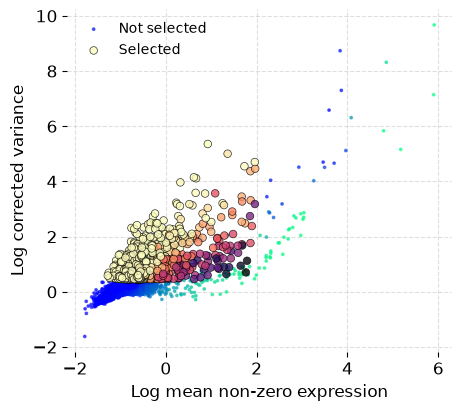

In [10]:
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3, 
    max_mean=2,
    max_var=6
)

In [11]:
normalized = ds.run_normalization(feat_key='hvgs')
pca = ds.run_pca(normalized, dims=25)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ds.load_graph()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 390558 stored elements and shape (18598, 18598)>

In [12]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True
)

In [13]:
ds.cells.to_pandas_dataframe(
    ['sample_id', 'RNA_UMAP1', 'RNA_UMAP2'],
    key='I'
).head()

,sample_id,RNA_UMAP1,RNA_UMAP2
2,ctrl,-19.465185,9.313817
3,ctrl,-15.292137,19.003984
4,ctrl,0.378579,14.985129
6,ctrl,-13.125798,16.785484
9,ctrl,28.072451,17.412685


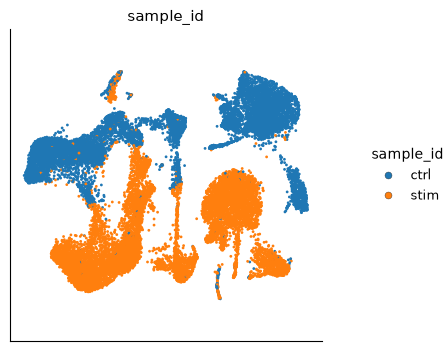

In [14]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='sample_id',
    legend_loc='right',
)

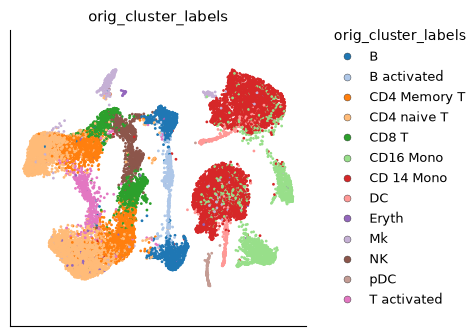

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
)

In [16]:
ds.cells.insert(
    column_name=f'is_ctrl',
    values=(ds.cells.fetch_all('sample_id') == 'ctrl'),
    overwrite=True
)

In [17]:
pca_partial = ds.run_pca(normalized, dims=25, pca_cell_key='is_ctrl')
ds.build_embedding_initialization(pca_partial)
ann = ds.build_ann_index(pca_partial)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label='pUMAP'
)

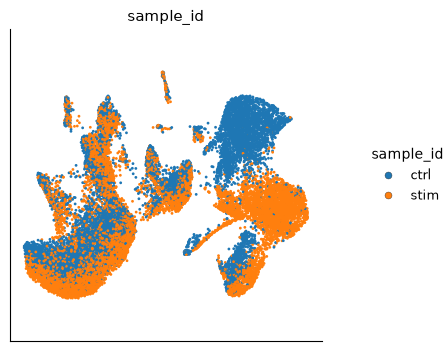

In [18]:
ds.plots.embedding(
    layout_key='RNA_pUMAP',
    color_by='sample_id',
    legend_loc='right',
)

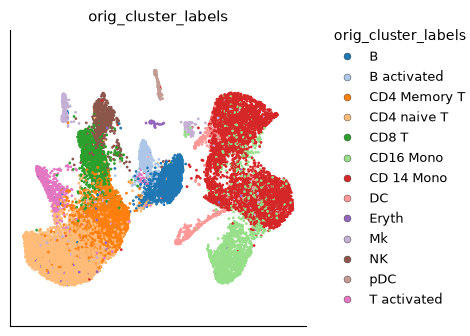

In [19]:
ds.plots.embedding(
    layout_key='RNA_pUMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
)

In [20]:
pca_full = ds.run_pca(normalized, dims=25)
corrected = ds.run_harmony(['sample_id'], pca_full)
ds.build_embedding_initialization(pca_full)
ann = ds.build_ann_index(corrected)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label='hUMAP'
)

ds.run_leiden_clustering(resolution=1.0)

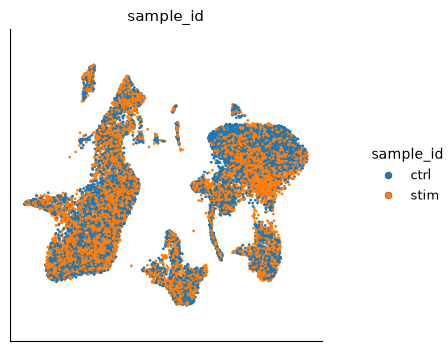

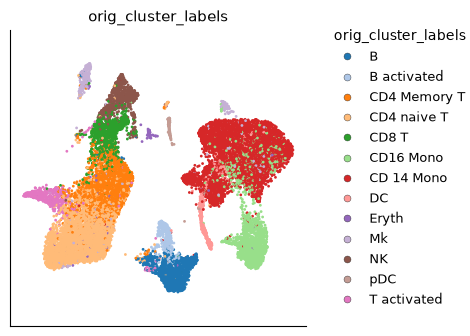

In [21]:
ds.plots.embedding(
    layout_key='RNA_hUMAP',
    color_by='sample_id',
    legend_loc='right',
)

ds.plots.embedding(
    layout_key='RNA_hUMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
)

In [22]:
import numpy as np
import pandas as pd

lisi = ds.metric_lisi(
    label_colnames=['sample_id', 'orig_cluster_labels'],
    save_result=True,
    perplexity=7,
)
pd.DataFrame(
    [
        {
            'label': label,
            'median': float(np.median(scores)),
            'mean': float(np.mean(scores)),
        }
        for label, scores in lisi
    ]
)

,label,median,mean
0,sample_id,1.489621,1.500446
1,orig_cluster_labels,1.011889,1.197259


In [23]:
pd.Series(
    {
        'iLISI (batch mixing)': ds.metric_ilisi(
            batch_colname='sample_id',
            perplexity=7,
        ),
        'cLISI (label purity)': ds.metric_clisi(
            label_colname='orig_cluster_labels',
            perplexity=7,
        ),
        'proportional batch mixing': ds.metric_proportional_batch_mixing(
            label_colname='sample_id',
            perplexity=7,
        ),
        'graph connectivity': ds.metric_graph_connectivity(
            label_colname='orig_cluster_labels',
        ),
        'label concordance (ARI)': ds.metric_label_concordance(
            label_columns=['RNA_leiden_cluster', 'orig_cluster_labels'],
            metric='ari',
        ),
    }
).round(3)

iLISI (batch mixing)         0.490
cLISI (label purity)         0.999
proportional batch mixing    0.508
graph connectivity           0.957
label concordance (ARI)      0.509
dtype: float64

In [24]:
silhouette = ds.metric_graph_silhouette(res_label='leiden_cluster')
pd.Series(silhouette).describe().round(3)

count    17.000
mean      0.151
std       0.198
min      -0.378
25%       0.107
50%       0.139
75%       0.260
max       0.509
dtype: float64